In [1]:
import time

import matplotlib.pyplot as plt

from utils import ImageGen
from path import findPath
from sokoban import findSolution

%load_ext autoreload
%autoreload 2

In [117]:
# seems time performance is pretty all-over-the-place and inconsistent

env = [
  [0, 0, 0, 0],
  [0, 1, 0, 0],
  [2, 1, 0, 0],
  [0, 1, 0, 0],
]

steps = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
times = []

for step in steps:
  t1 = time.time()
  positions = findPath(env, 6, step)
  t2 = time.time()
  
  dt = t2 - t1
  
  times.append(dt)
  print(f'step={step}: {dt}s')
  print(f'step={step} actual number of steps: {len(positions)}')

step=5: 0.022780895233154297s
step=5 actual number of steps: 4
step=10: 0.039565086364746094s
step=10 actual number of steps: 7
step=15: 0.07485008239746094s
step=15 actual number of steps: 2
step=20: 0.14844393730163574s
step=20 actual number of steps: 13
step=25: 0.20757102966308594s
step=25 actual number of steps: 18
step=30: 0.32824087142944336s
step=30 actual number of steps: 29
step=35: 0.44037508964538574s
step=35 actual number of steps: 18
step=40: 0.5624420642852783s
step=40 actual number of steps: 16
step=45: 0.6621179580688477s
step=45 actual number of steps: 22
step=50: 0.9541950225830078s
step=50 actual number of steps: 16


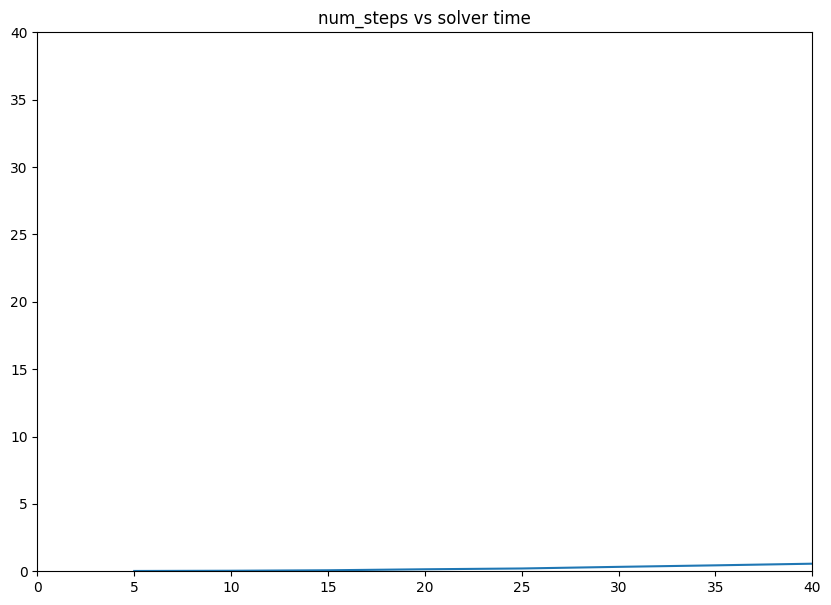

In [118]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(steps, times)
ax.set_title('num_steps vs solver time')
ax.set_xbound(0, 40)
ax.set_ybound(0, 40)

In [ ]:
env = [
    [0, 3, 0, 0],
    [3, 3, 0, 0],
    [0, 0, 3, 0],
    [0, 1, 2, 1],
]

steps = [3, 6, 9, 12, 15, 18]
times = []

for step in steps:
  t1 = time.time()
  positions = findSolution(env, 0, 3)
  t2 = time.time()
  
  dt = t2 - t1
  
  times.append(dt)
  print(f'step={step}: {dt}s')
  print(f'step={step} actual number of steps: {len(positions)}')

Visualization

In [2]:
env = [
    [0, 3, 0],
    [3, 3, 1],
    [0, 0, 0],
]
n = len(env)
k = 2

model = findSolution(env, 0, k)
image_gen = ImageGen()

0
0
1


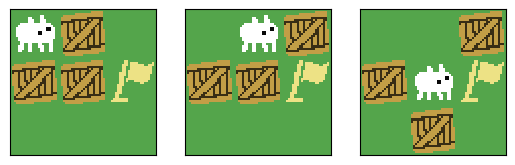

In [3]:
imgs = image_gen.generate_sequence(model, n, k)

fig, ax = plt.subplots(ncols = k+1)

for i in range(k+1):
  ax[i] = ax[i].imshow(imgs[i],  interpolation='nearest')
  ax[i].axes.xaxis.set_visible(False)
  ax[i].axes.yaxis.set_visible(False)

plt.show()

In [20]:
env = [
    [0, 3, 0, 0],
    [3, 3, 0, 0],
    [0, 0, 3, 0],
    [0, 2, 1, 2],
]
n = len(env)
k = 3

model = findSolution(env, 0, k)

if model is not None:
  print("found a model")
else:
  print("UNSAT")

found a model


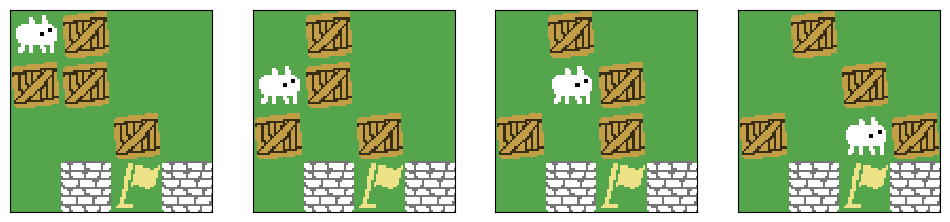

In [21]:
image_gen = ImageGen()
imgs = image_gen.generate_sequence(model, n, k, )

fig, ax = plt.subplots(ncols = k+1, figsize=(12, 5))

for i in range(k+1):
  ax[i] = ax[i].imshow(imgs[i], interpolation='nearest')
  ax[i].axes.xaxis.set_visible(False)
  ax[i].axes.yaxis.set_visible(False)

plt.show()